In [19]:
import torch
import mlflow
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import matplotlib

In [154]:
model = mlflow.pytorch.load_model('./mlruns/0/2dd8b16993c94c1391390cb497accbe7/artifacts/best_ad_mean')
position = torch.tensor(np.load('data/position.npy'))

In [155]:
noise = torch.randn((3288, 6))

In [157]:
position.shape

torch.Size([12])

In [134]:
def sample(noise, position, *args, **kwargs):

    y_samples = []

    for i, z in enumerate(noise):
        gpr = model.gprs[i]
        y_mean, y_cov = gpr.predict(position.reshape(2, -1).T, return_cov=True)
        b = np.linalg.cholesky(y_cov)
        y_samples.append(y_mean + np.dot(b, z))

    return torch.tensor(np.array(y_samples))


In [93]:
sample(noise[:1], position)

tensor([[ 0.0476, -1.1592, -1.1768,  0.3920, -0.1360, -0.3855]],
       dtype=torch.float64)

In [102]:
def plot(day, dlat1, dlat2, dlat3, dlat4, dlat5, dlat6, dlon1, dlon2, dlon3, dlon4, dlon5, dlon6):
    
    fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
    
    position_new = position + torch.tensor([dlat1, dlat2, dlat3, dlat4, dlat5, dlat6, dlon1, dlon2, dlon3, dlon4, dlon5, dlon6])
    sst = sample(noise, position)[day]
    sst_new = sample(noise, position_new)[day]

    cmap = matplotlib.cm.get_cmap('viridis')
    norm = matplotlib.colors.Normalize(vmin=sst.min(), vmax=sst.max())

    lat, lon = position[:6], position[6:]
    for i, (lat, lon) in enumerate(zip(lat, lon)):
        ax[0].scatter(lon, lat, color=cmap(norm(sst[i])), cmap='viridis', s=100)
        ax[0].set_xlim((-15, 15))
        ax[0].set_ylim((-15, 15))

    lat, lon = position_new[:6], position_new[6:]
    for i, (lat, lon) in enumerate(zip(lat, lon)):
        ax[1].scatter(lon, lat, color=cmap(norm(sst_new[i])), cmap='viridis', s=100)
        ax[1].set_xlim((-15, 15))
        ax[1].set_ylim((-15, 15))


In [103]:
interact(plot,
         day=widgets.IntSlider(min=0, max=3288, step=1, value=0),
         dlat1=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlat2=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlat3=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlat4=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlat5=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlat6=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlon1=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlon2=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlon3=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlon4=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlon5=widgets.IntSlider(min=-10, max=10, step=1, value=0),
         dlon6=widgets.IntSlider(min=-10, max=10, step=1, value=0))

interactive(children=(IntSlider(value=0, description='day', max=3288), IntSlider(value=0, description='dlat1',…

<function __main__.plot(day, dlat1, dlat2, dlat3, dlat4, dlat5, dlat6, dlon1, dlon2, dlon3, dlon4, dlon5, dlon6)>

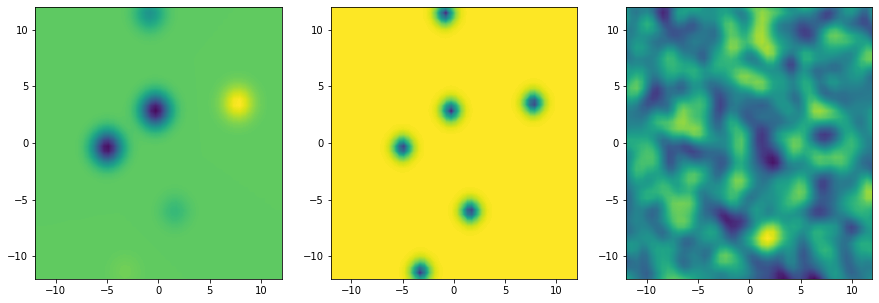

In [191]:
fig, ax = plt.subplots(figsize=(15, 5), ncols=3)

gridsize = 48

x = torch.linspace(-12, 12, gridsize)
y = torch.linspace(-12, 12, gridsize)
X, Y = torch.meshgrid(x, y)
posgrid = torch.cat([X.reshape(-1), Y.reshape(-1)])
noise = torch.randn((1, gridsize**2))

mean, cov = model.gprs[0].predict(posgrid.reshape(2, -1).T, return_cov=True)
mean, std = model.gprs[0].predict(posgrid.reshape(2, -1).T, return_std=True)
mean = mean.reshape(gridsize, gridsize)
std = std.reshape(gridsize, gridsize)

ax[0].contourf(X, Y, mean, 200)
ax[1].contourf(X, Y, std, 200)

samples = sample(noise, posgrid).reshape(gridsize, gridsize)
ax[2].contourf(X, Y, samples, 200)
